In [94]:
# Customer Segmentation using RFM Analysis and K-Means
# Project Overview
# يهدف هذا المشروع إلى تقسيم العملاء إلى مجموعات مختلفة بناءً على سلوكهم الشرائي.
# سنستخدم تحليل RFM، والذي يعتمد على ثلاثة مقاييس رئيسية
# - Recency: مدى حداثة آخر عملية شراء للعميل.
# - Frequency: عدد عمليات الشراء التي قام بها العميل.
# - Monetary: إجمالي المبلغ الذي أنفقه العميل.

In [95]:
# بيعمل نسخه من الملف علي جيتهاب عندي علي كولاب علشان نوصل للملفات والداتا الموجوده جواه-
!git clone https://github.com/HozaifaMoustafa/arabian-ai-training.git
# بعمل استدعاء للمكتبه علشان اقدر اشوف الملفات اللي جوهفولدر المشروع
import os
os.listdir("arabian-ai-training/01-ml-project")
# بستدعاء المكتبه علشان نتعامل مع الداتا ونقراها
import pandas as pd
df = pd.read_csv(
    "arabian-ai-training/01-ml-project/retail_transactions_segmentation.csv"
)


fatal: destination path 'arabian-ai-training' already exists and is not an empty directory.


In [96]:
# استيراد المكتبات
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [97]:
# فحص وفهم البيانات
# عرض عدد الصفوف والأعمدة الموجودة في الداتا
print("حجم الداتا:")
print(df.shape)


# عرض أسماء الأعمدة الموجودة في الداتا
print("\nأسماء الأعمدة:")
print(df.columns)


# عرض نوع البيانات الموجودة في كل عمود
print("\nنوع البيانات في كل عمود:")
print(df.dtypes)


# التحقق من وجود قيم مفقودة في الداتا
print("\nعدد القيم المفقودة في كل عمود:")
print(df.isnull().sum())


# عرض إحصائيات وصفية للأعمدة الرقمية
print("\nالإحصائيات الوصفية:")
display(df.describe())

حجم الداتا:
(3663, 4)

أسماء الأعمدة:
Index(['customer_id', 'transaction_date', 'amount', 'product_category'], dtype='object')

نوع البيانات في كل عمود:
customer_id           int64
transaction_date     object
amount              float64
product_category     object
dtype: object

عدد القيم المفقودة في كل عمود:
customer_id         0
transaction_date    0
amount              0
product_category    0
dtype: int64

الإحصائيات الوصفية:


,customer_id,amount
count,3663.000000,3663.000000
mean,5147.309036,513.028376
std,85.189230,305.332100
min,5001.000000,5.000000
25%,5073.000000,276.550000
50%,5142.000000,411.870000
75%,5223.000000,767.740000
max,5300.000000,1506.360000


In [98]:
#  عمود التاريخ
# تحويل transaction_date من نص إلى تاريخ
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"]
)
# التأكد من نوع العمود بعد التحويل
print("نوع transaction_date بعد التحويل:")
print(df["transaction_date"].dtype)

نوع transaction_date بعد التحويل:
datetime64[ns]


In [99]:
# Class الخاصة بمشروع Customer Segmentation

class CustomerSegmentation:

    def __init__(self, data, random_state=42):

        # عمل نسخة من الداتا الأصلية
        self.data = data.copy()

        # تثبيت random_state
        # حتى تكون النتائج قابلة للتكرار
        self.random_state = random_state

        # جدول RFM
        self.rfm = None

        # البيانات بعد الـScaling
        self.scaled_rfm = None

        # الـScaler
        self.scaler = None

        # القيم التي سنجربها لعدد الـClusters
        self.k_values = range(2, 11)

        # تخزين قيم Inertia
        self.inertias = []

        # تخزين قيم Silhouette Score
        self.silhouette_scores = []

        # تخزين قيمة k المختارة
        self.chosen_k = None

        # نموذج K-Means
        self.kmeans = None

        # نموذج PCA
        self.pca = None

        # بيانات PCA
        self.pca_data = None


    # ========================================================
    # Point 1 — RFM Analysis
    # ========================================================

    def create_rfm(self):


        # تحديد Reference Date
        # سنستخدم أكبر تاريخ موجود في الداتا
        # كـ Reference Date لحساب Recency
        reference_date = self.data["transaction_date"].max()
        print("Reference Date المستخدمة:")
        print(reference_date)

        # إنشاء جدول RFM
        self.rfm = self.data.groupby("customer_id").agg(

            # آخر تاريخ قام فيه العميل بالشراء
            last_purchase=("transaction_date", "max"),

            # عدد عمليات الشراء للعميل
            Frequency=("customer_id", "count"),

            # إجمالي المبلغ الذي أنفقه العميل
            Monetary=("amount", "sum")

        ).reset_index()


        # حساب Recency
        # عدد الأيام منذ آخر عملية شراء
        self.rfm["Recency"] = (
            reference_date - self.rfm["last_purchase"]
        ).dt.days


        # حذف العمود المؤقت
        self.rfm.drop(
            columns=["last_purchase"],
            inplace=True
        )


        # ترتيب الأعمدة
        self.rfm = self.rfm[
            [
                "customer_id",
                "Recency",
                "Frequency",
                "Monetary"
            ]
        ]


        # عرض أول 5 صفوف
        print("\nأول 5 صفوف من جدول RFM:")
        display(self.rfm.head())


        # عرض حجم الجدول
        print("\nحجم جدول RFM:")
        print(self.rfm.shape)


        # عرض عدد العملاء
        print("\nعدد العملاء:")
        print(self.rfm["customer_id"].nunique())


        return self.rfm

    # Point 2 — Feature Scaling
       def scale_features(self):

        # اختيار أعمدة RFM فقط
        rfm_features = self.rfm[
            [
                "Recency",
                "Frequency",
                "Monetary"
            ]
        ]


        # إنشاء StandardScaler
        self.scaler = StandardScaler()


        # عمل Scaling للـRFM
        self.scaled_rfm = self.scaler.fit_transform(
            rfm_features
        )


        # تحويل النتائج إلى DataFrame
        self.scaled_rfm = pd.DataFrame(
            self.scaled_rfm,
            columns=[
                "Recency",
                "Frequency",
                "Monetary"
            ],
            index=self.rfm.index
        )


        # عرض أول 5 صفوف
        print("أول 5 صفوف بعد الـScaling:")
        display(self.scaled_rfm.head())


        return self.scaled_rfm



    # Point 3 — Elbow + Silhouette
       def evaluate_k(self):

        # تفريغ النتائج في حالة إعادة تشغيل الـMethod
        self.inertias = []
        self.silhouette_scores = []


        # تجربة قيم k من 2 إلى 10
        for k in self.k_values:

            # إنشاء نموذج K-Means
            kmeans = KMeans(
                n_clusters=k,
                random_state=self.random_state,
                n_init=10
            )


            # تدريب النموذج
            labels = kmeans.fit_predict(
                self.scaled_rfm
            )


            # تخزين Inertia
            self.inertias.append(
                kmeans.inertia_
            )


            # حساب Silhouette Score
            score = silhouette_score(
                self.scaled_rfm,
                labels
            )

            self.silhouette_scores.append(score)


        # إنشاء جدول بالنتائج
        results = pd.DataFrame({
            "k": list(self.k_values),
            "Inertia": self.inertias,
            "Silhouette Score": self.silhouette_scores
        })


        print("نتائج قيم k:")
        display(results)



        # Elbow Method


        plt.figure(figsize=(8, 5))

        plt.plot(
            list(self.k_values),
            self.inertias,
            marker="o"
        )

        plt.xlabel("Number of Clusters (k)")
        plt.ylabel("Inertia")
        plt.title("Elbow Method")

        plt.xticks(list(self.k_values))
        plt.grid(True)

        plt.show()



        # Silhouette Score
         plt.figure(figsize=(8, 5))

        plt.plot(
            list(self.k_values),
            self.silhouette_scores,
            marker="o"
        )

        plt.xlabel("Number of Clusters (k)")
        plt.ylabel("Silhouette Score")
        plt.title("Silhouette Score")

        plt.xticks(list(self.k_values))
        plt.grid(True)

        plt.show()


        return results



    # اختيار k

    def choose_k(self, k):

        # حفظ قيمة k التي اخترناها
        self.chosen_k = k

        print("تم اختيار k =", self.chosen_k)

        return self.chosen_k



    # Point 4 — K-Means

    def apply_kmeans(self):

        # التأكد من اختيار k
        if self.chosen_k is None:

            raise ValueError(
                "يجب اختيار k أولاً."
            )


        # إنشاء نموذج K-Means
        self.kmeans = KMeans(
            n_clusters=self.chosen_k,
            random_state=self.random_state,
            n_init=10
        )


        # تدريب K-Means على البيانات الـScaled
        self.rfm["Cluster"] = (
            self.kmeans.fit_predict(
                self.scaled_rfm
            )
        )


        # عرض أول 5 صفوف
        print("RFM بعد إضافة الـCluster:")
        display(self.rfm.head())


        return self.rfm



    # Point 5 — PCA Visualization:
    def apply_pca(self):

        # إنشاء PCA بمكونين
        self.pca = PCA(
            n_components=2
        )


        # تطبيق PCA على البيانات الـScaled
        self.pca_data = self.pca.fit_transform(
            self.scaled_rfm
        )


        # إنشاء DataFrame للـPCA
        pca_df = pd.DataFrame(
            self.pca_data,
            columns=[
                "PC1",
                "PC2"
            ]
        )


        # إضافة الـCluster
        pca_df["Cluster"] = (
            self.rfm["Cluster"].values
        )


        # رسم الـClusters
        plt.figure(figsize=(10, 6))


        # رسم كل Cluster
        for cluster in sorted(
            pca_df["Cluster"].unique()
        ):

            cluster_data = pca_df[
                pca_df["Cluster"] == cluster
            ]

            plt.scatter(
                cluster_data["PC1"],
                cluster_data["PC2"],
                label=f"Cluster {cluster}",
                alpha=0.7
            )


        # أسماء المحاور
        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")

        # عنوان الرسم
        plt.title(
            "Customer Segmentation using PCA"
        )

        # الـLegend
        plt.legend()

        plt.grid(True)

        plt.show()


        return pca_df



    # Point 6 — Cluster Analysis

    def analyze_clusters(self):

        # حساب متوسط RFM لكل Cluster
        cluster_summary = (
            self.rfm
            .groupby("Cluster")[
                [
                    "Recency",
                    "Frequency",
                    "Monetary"
                ]
            ]
            .mean()
            .round(2)
        )


        print("متوسط RFM لكل Cluster:")
        display(cluster_summary)


        return cluster_summary

In [100]:
# ============================================================
# إنشاء Object من الـClass
# ============================================================

customer_segmentation = CustomerSegmentation(
    df,
    random_state=42
)

In [101]:
# بناء جدول RFM
rfm = customer_segmentation.create_rfm()

Reference Date المستخدمة:
2024-12-30 00:00:00

أول 5 صفوف من جدول RFM:


,customer_id,Recency,Frequency,Monetary
0,5001,1,16,5172.45
1,5002,22,18,6158.98
2,5003,36,3,654.12
3,5004,4,35,31050.88
4,5005,25,16,5700.91



حجم جدول RFM:
(300, 4)

عدد العملاء:
300


In [102]:
# Point 2 — Feature Scaling
# اختيار أعمدة RFM التي سنستخدمها في الـClustering
rfm_features = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]


# إنشاء StandardScaler
scaler = StandardScaler()


# عمل Scaling للبيانات
scaled_rfm = scaler.fit_transform(
    rfm_features
)


# تحويل البيانات بعد الـScaling إلى DataFrame
scaled_rfm = pd.DataFrame(
    scaled_rfm,
    columns=[
        "Recency",
        "Frequency",
        "Monetary"
    ]
)


# عرض أول 5 صفوف بعد الـScaling
print("أول 5 صفوف بعد  Scaling :")
display(scaled_rfm.head())

أول 5 صفوف بعد  Scaling :


,Recency,Frequency,Monetary
0,-0.772792,0.356692,-0.113196
1,-0.464634,0.544920,-0.010898
2,-0.259195,-0.866790,-0.581723
3,-0.728770,2.144859,2.570262
4,-0.420611,0.356692,-0.058397


In [103]:
# Point 3 — اختيار عدد الـClusters
# قائمة لتخزين قيم Inertia
inertias = []

# قائمة لتخزين قيم Silhouette Score
silhouette_scores = []

# القيم التي سنجربها لعدد الـClusters
k_values = range(2, 11)

# تجربة قيم k من 2 إلى 10
for k in k_values:

    # إنشاء نموذج K-Means
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # تدريب النموذج على البيانات بعد الـScaling
    labels = kmeans.fit_predict(scaled_rfm)

    # حفظ قيمة Inertia
    inertias.append(kmeans.inertia_)

    # حساب Silhouette Score
    score = silhouette_score(
        scaled_rfm,
        labels
    )

    # حفظ قيمة الـScore
    silhouette_scores.append(score)



# إنشاء جدول لعرض النتائج

k_results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

print("نتائج تجربة قيم k:")
display(k_results)

نتائج تجربة قيم k:


,k,Inertia,Silhouette Score
0,2,394.208028,0.678910
1,3,183.032138,0.678170
2,4,93.388049,0.570227
3,5,71.407066,0.523155
4,6,50.343627,0.519382
5,7,41.125688,0.462554
6,8,30.223591,0.481482
7,9,24.119083,0.482195
8,10,21.074266,0.476483


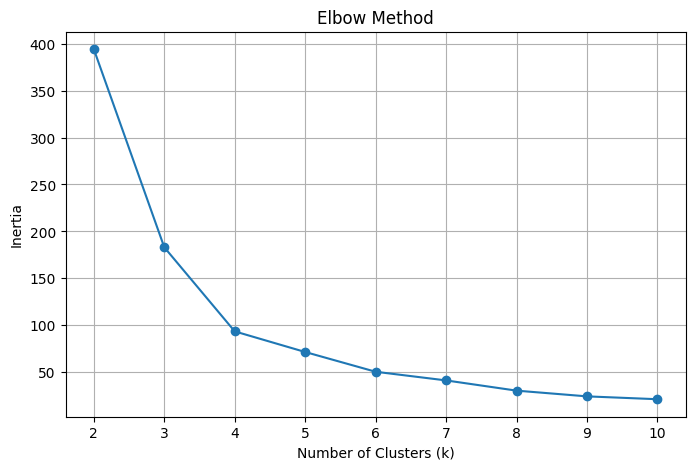

In [104]:
# Elbow Method
plt.figure(figsize=(8, 5))

# رسم عدد الـClusters مقابل Inertia
plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

# تسمية المحاور
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

# عنوان الرسم
plt.title("Elbow Method")

# إظهار قيم k على المحور الأفقي
plt.xticks(list(k_values))

# إضافة Grid لتسهيل قراءة الرسم
plt.grid(True)

plt.show()

In [105]:
# بناءً على نتائج Elbow Method و Silhouette Score
# اخترنا استخدام 3 Clusters
chosen_k = 3

print("العدد المختار:", chosen_k)

العدد المختار: 3


In [106]:
# Point 4 — تطبيق K-Means Clustering
kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)


# تدريب النموذج على بيانات RFM بعد الـScaling
# والحصول على رقم الـCluster لكل عميل
cluster_labels = kmeans.fit_predict(
    scaled_rfm
)


# إضافة رقم الـCluster إلى جدول RFM
rfm["Cluster"] = cluster_labels

# عرض النتائج
# عرض أول 5 عملاء بعد إضافة الـCluster
print("أول 5 صفوف بعد تطبيق K-Means:")
display(rfm.head())


# عرض عدد العملاء الموجودين في كل Cluster
print("\nعدد العملاء في كل Cluster:")
print(
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

أول 5 صفوف بعد تطبيق K-Means:


,customer_id,Recency,Frequency,Monetary,Cluster
0,5001,1,16,5172.45,1
1,5002,22,18,6158.98,1
2,5003,36,3,654.12,1
3,5004,4,35,31050.88,0
4,5005,25,16,5700.91,1



عدد العملاء في كل Cluster:
Cluster
0     40
1    238
2     22
Name: count, dtype: int64


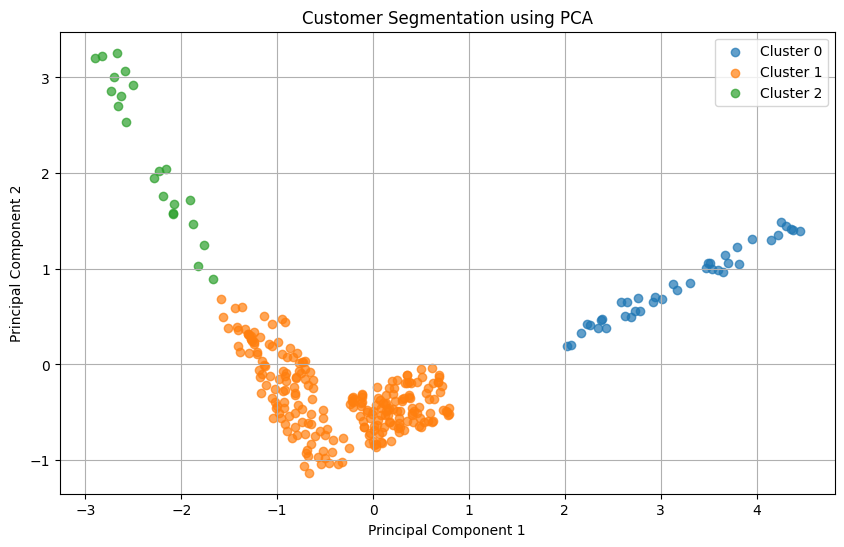

In [107]:
# Point 5 — PCA Visualization
# إنشاء PCA باستخدام مكونين رئيسيين
pca = PCA(
    n_components=2
)


# تطبيق PCA على بيانات RFM بعد الـScaling
pca_data = pca.fit_transform(
    scaled_rfm
)


# تحويل نتائج PCA إلى DataFrame
pca_df = pd.DataFrame(
    pca_data,
    columns=[
        "PC1",
        "PC2"
    ]
)


# إضافة رقم الـCluster لكل عميل
pca_df["Cluster"] = rfm["Cluster"].values


# رسم الـClusters
plt.figure(figsize=(10, 6))


# رسم كل Cluster بشكل منفصل
for cluster in sorted(pca_df["Cluster"].unique()):

    # اختيار العملاء الموجودين في الـCluster الحالي
    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    # رسم العملاء
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )


# تسمية المحاور
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")


# إضافة عنوان للرسم
plt.title(
    "Customer Segmentation using PCA"
)


# إظهار الـLegend
plt.legend()


# إضافة Grid
plt.grid(True)


# عرض الرسم
plt.show()

In [108]:
# Point 6 — تحليل الـClusters

# حساب متوسط Recency و Frequency و Monetary لكل Cluster
cluster_summary = rfm.groupby("Cluster")[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].mean().round(2)


# عرض متوسطات RFM لكل Cluster
print("متوسط RFM لكل Cluster:")
display(cluster_summary)

متوسط RFM لكل Cluster:


,Recency,Frequency,Monetary
Cluster,,,
0,7.40,35.00,29683.61
1,42.59,9.32,2876.90
2,257.59,2.09,326.14


In [109]:
# إنشاء أسماء الـCustomer Personas

# ربط كل Cluster بالـPersona المناسبة له
persona_names = {
    0: "VIP Customers",
    1: "Regular Customers",
    2: "At-Risk / Dormant Customers"
}


# إضافة اسم الـPersona لكل عميل
rfm["Persona"] = rfm["Cluster"].map(
    persona_names
)


# عرض أول 5 صفوف بعد إضافة الـPersona
print("أول 5 صفوف بعد إضافة Customer Persona:")
display(rfm.head())

أول 5 صفوف بعد إضافة Customer Persona:


,customer_id,Recency,Frequency,Monetary,Cluster,Persona
0,5001,1,16,5172.45,1,Regular Customers
1,5002,22,18,6158.98,1,Regular Customers
2,5003,36,3,654.12,1,Regular Customers
3,5004,4,35,31050.88,0,VIP Customers
4,5005,25,16,5700.91,1,Regular Customers


In [110]:
# ملخص Customer Personas
# حساب متوسط RFM لكل Persona
persona_summary = rfm.groupby("Persona")[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].mean().round(2)


# عرض ملخص الـPersonas
print("ملخص Customer Personas:")
display(persona_summary)

ملخص Customer Personas:


,Recency,Frequency,Monetary
Persona,,,
At-Risk / Dormant Customers,257.59,2.09,326.14
Regular Customers,42.59,9.32,2876.90
VIP Customers,7.40,35.00,29683.61


In [111]:
# عدد العملاء في كل Persona
persona_counts = rfm["Persona"].value_counts()


print("عدد العملاء في كل Persona:")
display(persona_counts)

عدد العملاء في كل Persona:


,count
Persona,
Regular Customers,238
VIP Customers,40
At-Risk / Dormant Customers,22
